# Customer Retention and Sales Analysis using Cohort Analysis on Online Retail Data

## Objective
The objective of this analysis is to understand customer purchasing behavior and retention patterns using cohort analysis techniques.

In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned/cleaned_retail_day3.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   Sales        392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 43.8 MB


In [5]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
df[["InvoiceDate","InvoiceMonth"]].head()

,InvoiceDate,InvoiceMonth
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


## Cohort Feature Engineering

In this section, customer cohorts are created based on their first purchase month. This allows us to track customer retention over time and analyze repeat purchasing behavior.

In [7]:
df["CohortMonth"] = (df.groupby("CustomerID")["InvoiceDate"].transform("min").dt.to_period("M"))
df[["CustomerID","InvoiceMonth","CohortMonth"]].head()

,CustomerID,InvoiceMonth,CohortMonth
0,17850.0,2010-12,2010-12
1,17850.0,2010-12,2010-12
2,17850.0,2010-12,2010-12
3,17850.0,2010-12,2010-12
4,17850.0,2010-12,2010-12


In [8]:
year_diff = (df["InvoiceMonth"].dt.year -df["CohortMonth"].dt.year)

month_diff = (df["InvoiceMonth"].dt.month -df["CohortMonth"].dt.month)

df["CohortIndex"] = (year_diff * 12 +month_diff + 1)

In [9]:
df[["CustomerID","InvoiceMonth","CohortMonth","CohortIndex"]].head(20)

,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,17850.0,2010-12,2010-12,1
1,17850.0,2010-12,2010-12,1
2,17850.0,2010-12,2010-12,1
3,17850.0,2010-12,2010-12,1
4,17850.0,2010-12,2010-12,1
5,17850.0,2010-12,2010-12,1
6,17850.0,2010-12,2010-12,1
7,17850.0,2010-12,2010-12,1
8,17850.0,2010-12,2010-12,1
9,13047.0,2010-12,2010-12,1


In [10]:
df.to_csv("../data/cleaned/cohort_ready_dataset.csv",index=False)

In [4]:
import pandas as pd

df = pd.read_csv("../data/cleaned/cohort_ready_dataset.csv")

In [5]:
cohort_data = df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()

cohort_data.head()

,CohortMonth,CohortIndex,CustomerID
0,2010-12,1,885
1,2010-12,2,324
2,2010-12,3,286
3,2010-12,4,340
4,2010-12,5,321


## Retention Matrix

The retention matrix shows the percentage of customers from each cohort who returned in subsequent months.

In [6]:
cohort_counts = cohort_data.pivot(index="CohortMonth", columns="CohortIndex",values="CustomerID")

cohort_counts.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN


In [7]:
cohort_sizes = cohort_counts.iloc[:, 0]

retention = cohort_counts.divide( cohort_sizes,axis=0)

retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


## Retention Heatmap

The heatmap provides a visual representation of customer retention trends across different customer cohorts.

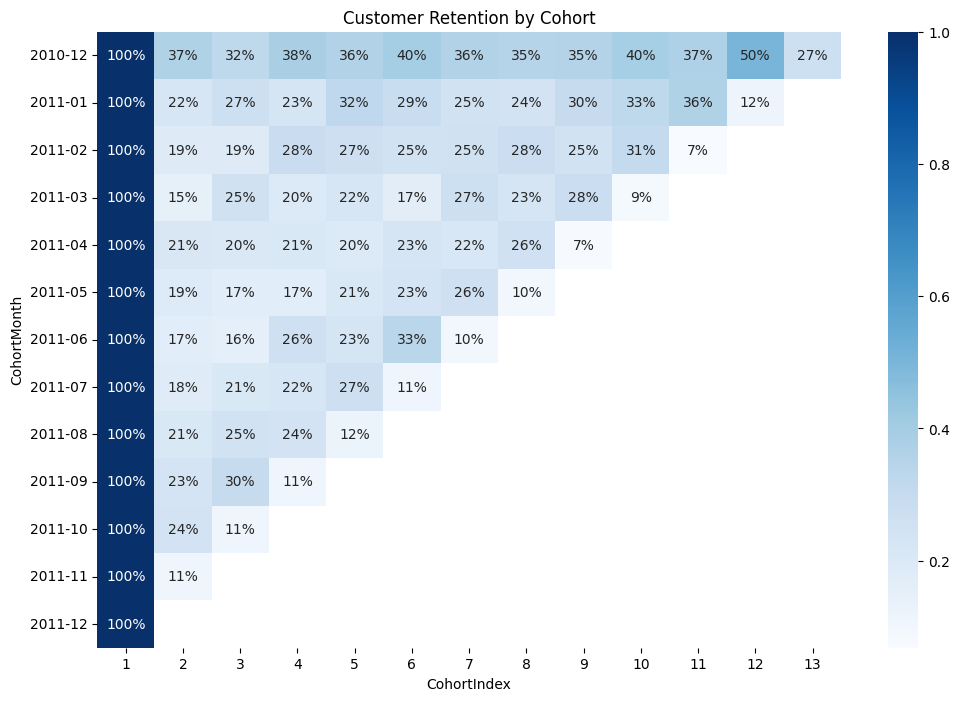

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(retention,annot=True,fmt=".0%",cmap="Blues")

plt.title("Customer Retention by Cohort")
plt.show()

## Cohort Analysis Insights

1. Customer retention is highest in the acquisition month (100%) and drops significantly in the second month across all cohorts, indicating that many customers make only a single purchase.

2. Most cohorts retain between 15% and 40% of customers after the first few months, showing moderate repeat purchase behavior.

3. The December 2010 cohort demonstrates some of the strongest long-term retention, maintaining approximately 50% retention even after 12 months, suggesting a highly loyal customer segment.

4. Several cohorts show temporary increases in retention at later periods, indicating that some customers return after being inactive for a few months.

5. Retention generally declines over time, highlighting customer churn as a key business challenge. Improving customer engagement and loyalty programs during the first few months after acquisition could help increase long-term retention.

## Conclusion

The cohort analysis reveals that customer retention decreases steadily over time, with the largest drop occurring after the first purchase. While a small group of loyal customers continues to make repeat purchases over several months, the majority of customers become inactive relatively quickly. These findings suggest that the business should focus on customer retention strategies such as personalized marketing, loyalty programs, and targeted promotions to encourage repeat purchases and improve long-term customer value.